In [ ]:
from google.colab import userdata
import os

# set Kaggle API credentials using Google Colab Secrets
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USER')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:
!kaggle datasets download -d ahsan81/hotel-reservations-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 480k/480k [00:00<00:00, 684kB/s]



In [ ]:
!unzip -q hotel-reservations-classification-dataset.zip -d hotel_reservations_data

In [ ]:
!ls hotel_reservations_data

'Hotel Reservations.csv'


In [27]:
%pip install eli5==0.16.0 catboost==1.2.10 shap==0.50.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import eli5
from eli5.sklearn import PermutationImportance

from catboost import CatBoostClassifier
import shap
from shap import TreeExplainer

In [ ]:
#load the dataset into a pandas DataFrame
df_hotel_res = pd.read_csv("/content/hotel_reservations_data/Hotel Reservations.csv")

In [ ]:
df_hotel_res

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [ ]:
df_hotel_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

<Axes: xlabel='booking_status'>

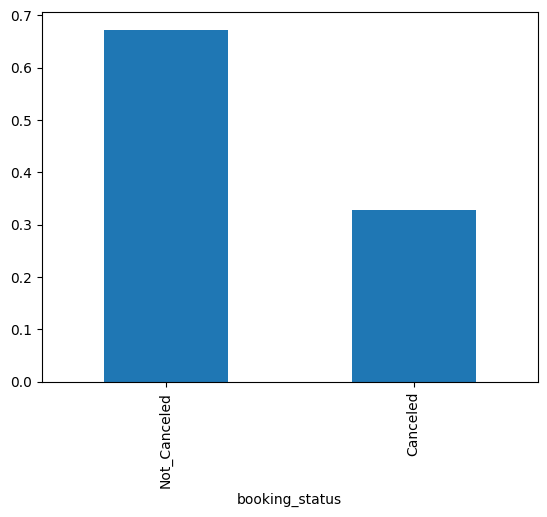

In [ ]:
df_hotel_res['booking_status'].value_counts(normalize=True).plot(kind='bar') #group sizes are uneven

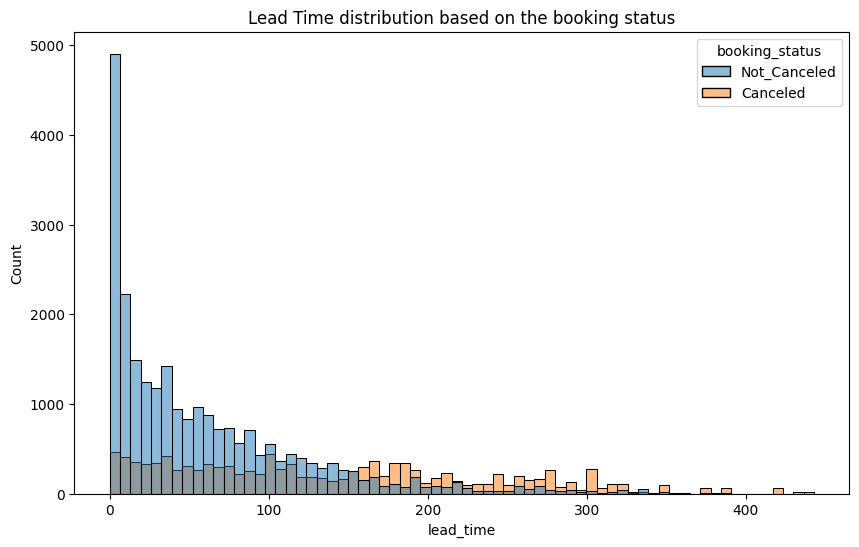

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_hotel_res, x = 'lead_time', hue = 'booking_status')
plt.title('Lead Time distribution based on the booking status')
plt.show()

The hypothesis: the longer the lead time, the higher the probability of cancellation

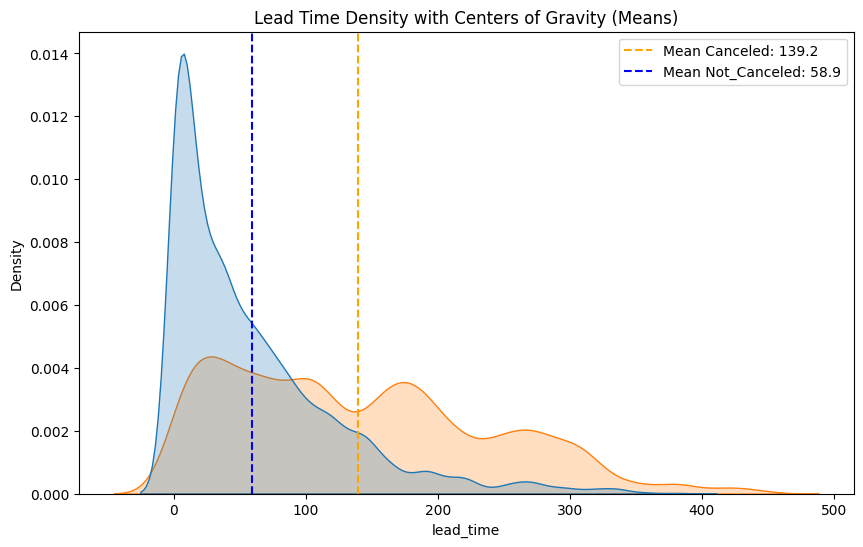

In [ ]:
# Average (center of gravity) for each group
mean_canceled = df_hotel_res[df_hotel_res['booking_status'] == 'Canceled']['lead_time'].mean()
mean_not_canceled = df_hotel_res[df_hotel_res['booking_status'] == 'Not_Canceled']['lead_time'].mean()

plt.figure(figsize=(10, 6))

# KDE
#common_norm=False tells the plotter to calculate densities independently for each subgroup ,
#rather than normalizing across the entire dataset. This is essential for comparing shapes when group sizes are uneven
sns.kdeplot(data=df_hotel_res, x='lead_time', hue='booking_status', fill=True, common_norm=False)

# Center of gravity lines
plt.axvline(mean_canceled, color='orange', linestyle='--', label=f'Mean Canceled: {mean_canceled:.1f}')
plt.axvline(mean_not_canceled, color='blue', linestyle='--', label=f'Mean Not_Canceled: {mean_not_canceled:.1f}')

plt.title('Lead Time Density with Centers of Gravity (Means)')
plt.legend()
plt.show()

While the distribution for confirmed reservations is unimodal and heavily skewed towards the left—with a sharp peak near the 0–20 day mark — the cancellation distribution is multimodal. This presence of several "peaks" (modes) in the orange distribution suggests that cancellations are not driven by a single factor. There are also significant clusters of cancellations at short notice, around the 100-day mark, and another peak near 150–200 days. These multiple modes indicate that as the planning horizon expands, new "waves" of cancellation risks emerge. There can be the so-called "zone of uncertainty" starting after 100 days.

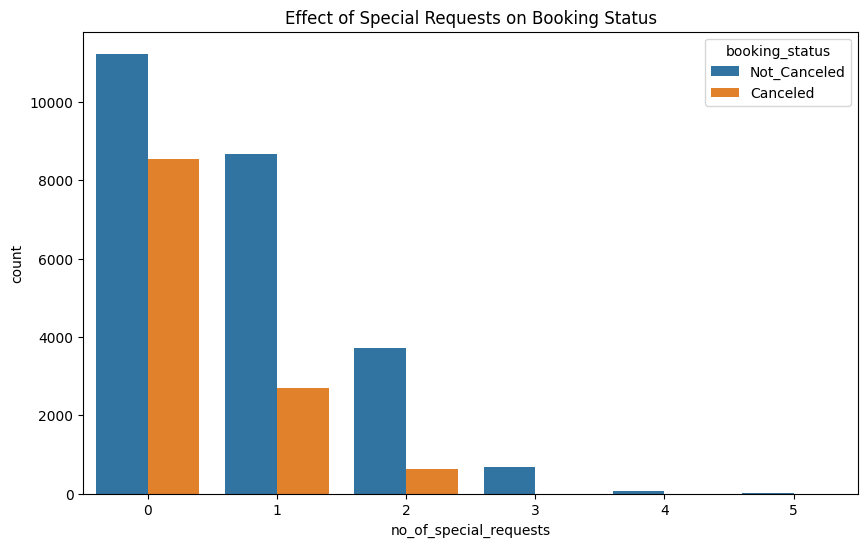

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_hotel_res, x='no_of_special_requests', hue='booking_status')
plt.title('Effect of Special Requests on Booking Status')
plt.show()

As the number of requests increases, the cancellation rate drops significantly. This suggests that "highly engaged" customers who personalize their stay are far more likely to stick to their booking.

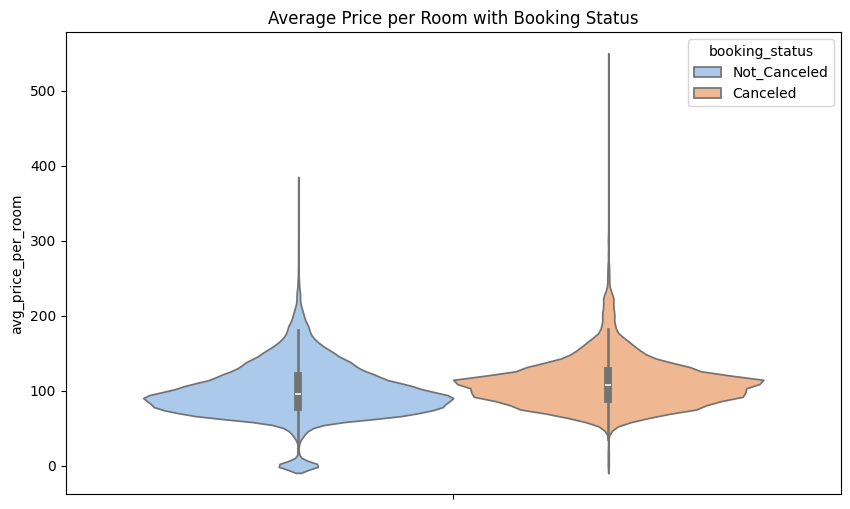

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_hotel_res, hue='booking_status', y='avg_price_per_room', palette = 'pastel')
plt.title('Average Price per Room with Booking Status')
plt.show()

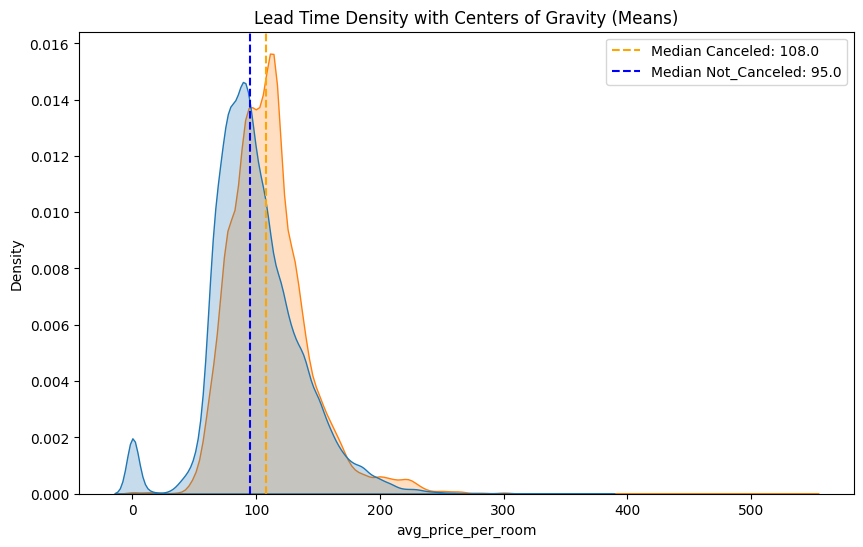

In [ ]:
median_canceled = df_hotel_res[df_hotel_res['booking_status'] == 'Canceled']['avg_price_per_room'].median()
median_not_canceled = df_hotel_res[df_hotel_res['booking_status'] == 'Not_Canceled']['avg_price_per_room'].median()

plt.figure(figsize=(10, 6))

# KDE
#common_norm=False tells the plotter to calculate densities independently for each subgroup ,
#rather than normalizing across the entire dataset. This is essential for comparing shapes when group sizes are uneven
sns.kdeplot(data=df_hotel_res, x='avg_price_per_room', hue='booking_status', fill=True, common_norm=False)

# Center of gravity lines
plt.axvline(median_canceled, color='orange', linestyle='--', label=f'Median Canceled: {median_canceled:.1f}')
plt.axvline(median_not_canceled, color='blue', linestyle='--', label=f'Median Not_Canceled: {median_not_canceled:.1f}')

plt.title('Lead Time Density with Centers of Gravity (Means)')
plt.legend()
plt.show()

The KDE plot reveals that the price distributions for canceled and confirmed bookings significantly overlap, with their medians positioned visually close to each other. However, subtle distinctions are present: the cancellation density (judging by the violin plots) is more concentrated at slightly higher price points.This suggests that average price per room is likely a secondary predictor with lower feature importance.

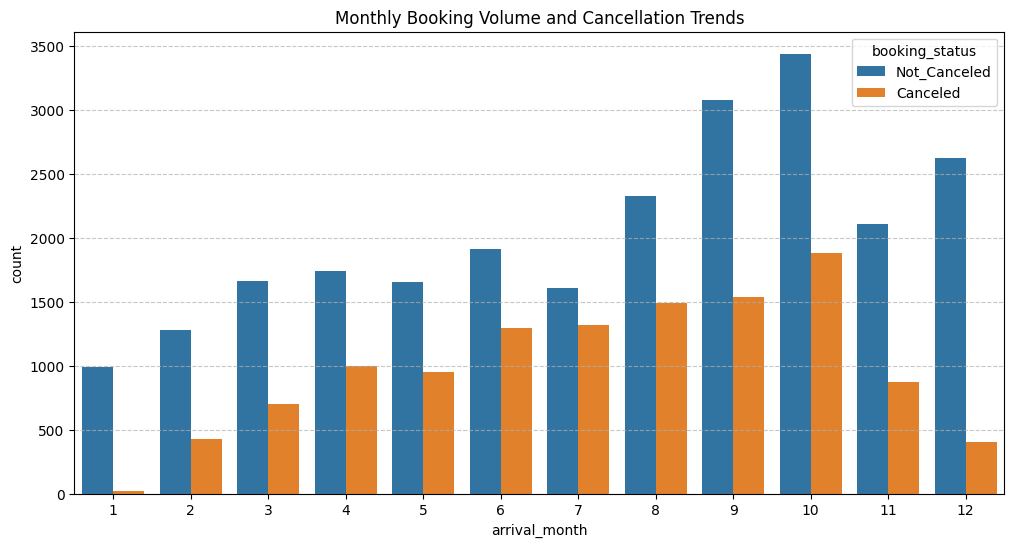

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_hotel_res, x='arrival_month', hue='booking_status')
plt.title('Monthly Booking Volume and Cancellation Trends')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The seasonal analysis reveals several distinct peculiarities. While the general cancellation rate is approximately 32.8%, this proportion is not uniformly distributed throughout the year.
1. Peak demand volatility: The months of September and October show the highest booking volumes, likely driven by regional events and late-season tourism. However, these peaks are accompanied by a disproportionately high volume of cancellations
2. Stability in winter: In contrast, December and January exhibit much higher booking stability. The ratio of cancellations to confirmed stays in these months is visibly lower than the dataset average
3. Summer uncertainty: July and August show a high 'cancellation-to-booking' ratio, indicating a more volatile market where guests likely secure multiple reservations before committing to one

In [ ]:
X_hotels, y_hotels = df_hotel_res.drop(columns=['booking_status', 'Booking_ID']), df_hotel_res['booking_status']
y_hotels = y_hotels.map({'Not_Canceled': 0, 'Canceled':1})

In [ ]:
hotels_num_feat = ['no_of_weekend_nights',	'no_of_week_nights', 'no_of_adults', 'no_of_children', 'lead_time', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']
hotels_cat_feat = ['type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'market_segment_type', 'repeated_guest', 'arrival_year', 'arrival_month', 'arrival_date']


In [ ]:
X_hotels_train, X_hotels_val, y_hotels_train, y_hotels_val = train_test_split(X_hotels, y_hotels, random_state=42, train_size=0.6, stratify = y_hotels)

X_hotels_train = X_hotels_train.reset_index(drop=True)
y_hotels_train.index = X_hotels_train.index
X_hotels_val = X_hotels_val.reset_index(drop=True)
y_hotels_val.index = X_hotels_val.index

In [ ]:
lr_preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), hotels_num_feat),
        #drop='first' to avoid multicollinearity
        ('cat', OneHotEncoder(drop='first'), hotels_cat_feat)
    ]
)
lr_pipeline = Pipeline(
    steps = [
        ('preprocessor', lr_preprocessor),
        ('model', LogisticRegression(random_state=42))
    ]
)

lr_param_grid = {
    'model__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
    'model__penalty': ['l2'],
}

scoring = 'roc_auc'
cv = 5

cv_lr_hotels = GridSearchCV(
    estimator = lr_pipeline,
    param_grid = lr_param_grid,
    scoring = scoring,
    cv=cv,
    n_jobs=-1
).fit(X_hotels_train, y_hotels_train)

lr_hotel = cv_lr_hotels.best_estimator_

In [ ]:
y_hotels_pred_lr = lr_hotel.predict(X_hotels_val)

print(classification_report(y_hotels_val, y_hotels_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      9756
           1       0.73      0.64      0.68      4754

    accuracy                           0.81     14510
   macro avg       0.78      0.76      0.77     14510
weighted avg       0.80      0.81      0.80     14510



In [ ]:
y_hotels_pred_proba_lr = lr_hotel.predict_proba(X_hotels_val)
roc_auc_score(y_hotels_val, y_hotels_pred_proba_lr[:,1])

np.float64(0.8736444379588936)

In [ ]:
from sklearn.inspection import permutation_importance

n_repeats = 5
scoring = 'roc_auc'

# get features names from the pipeline
feature_names = lr_hotel.named_steps['preprocessor'].get_feature_names_out()

#permutation_importance form sklearn
perm_lr_hotel = permutation_importance(
    lr_hotel, X_hotels_val, y_hotels_val,
    n_repeats=n_repeats,
    random_state=42,
    scoring=scoring
)

#create a DataFrame with the features and their mean importance with std
importance_df = pd.DataFrame({
    'feature': X_hotels_val.columns,
    'importance_mean': perm_lr_hotel.importances_mean,
    'importance_std': perm_lr_hotel.importances_std
}).sort_values(by='importance_mean', ascending=False)

print(importance_df)

                                 feature  importance_mean  importance_std
7                              lead_time         0.181752        0.003261
16                no_of_special_requests         0.117086        0.002056
11                   market_segment_type         0.057277        0.001676
15                    avg_price_per_room         0.033396        0.000868
9                          arrival_month         0.021755        0.001147
5             required_car_parking_space         0.005898        0.000749
12                        repeated_guest         0.004996        0.000601
10                          arrival_date         0.003466        0.000421
6                     room_type_reserved         0.002612        0.000425
8                           arrival_year         0.002214        0.000526
2                   no_of_weekend_nights         0.001790        0.000172
13          no_of_previous_cancellations         0.001202        0.000161
4                      type_of_meal_pl

In [ ]:
# top-2 important features
top_2_features = importance_df['feature'].iloc[:2].tolist()
top_2_features

['lead_time', 'no_of_special_requests']

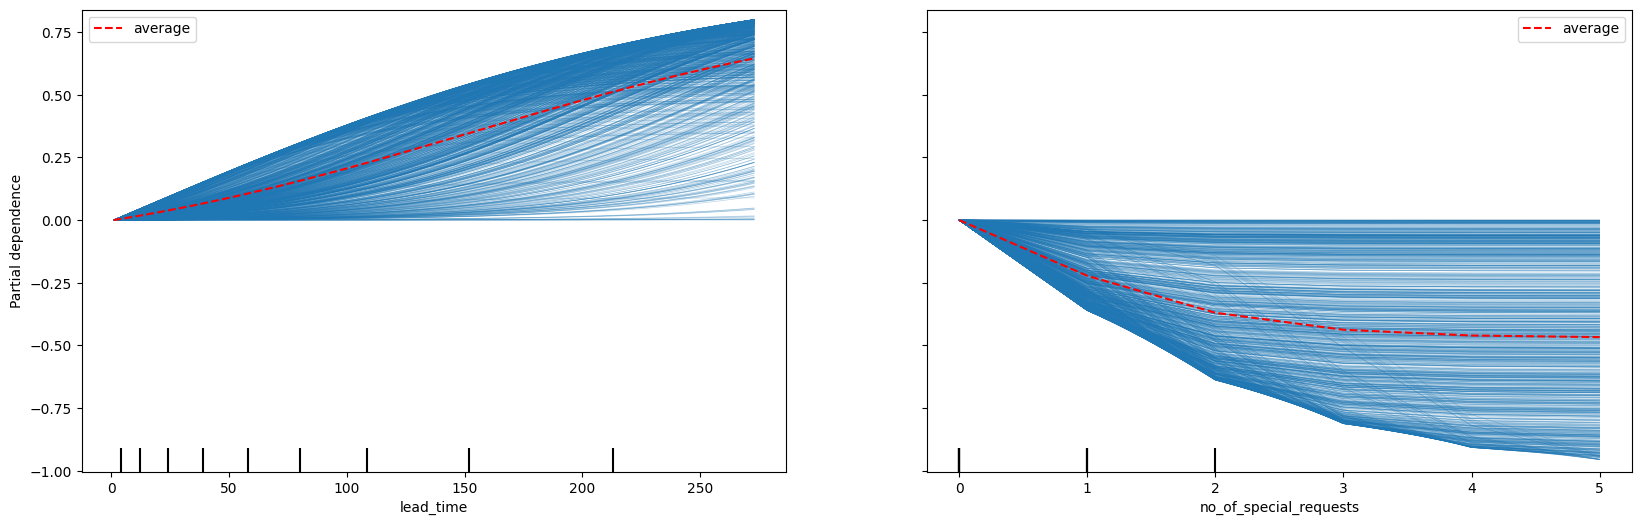

In [71]:
# PDP  for top-2 important features for lr_hotel
fig, ax = plt.subplots(figsize=(20, 6))
PartialDependenceDisplay.from_estimator(
    estimator=lr_hotel,
    X=X_hotels_val,
    features=top_2_features,
    centered=True,
    ax=ax,
    kind='both',
    pd_line_kw={'color': 'red'}
)

There is a strong positive relationship between lead time and the target variable. Longer booking windows significantly increase the probability of cancellation.
There is a clear negative correlation between the number of special requests and the target variable. An increase in special requests serves as a strong indicator of guest commitment.

SHAP is a game-theoretic approach to explain the output of a machine learning model. It decomposes a specific prediction into the additive contributions of its individual features. It measures how much each feature contributes to the deviation of a specific prediction from the average baseline prediction

SHAP provides not only local interpretability (explaining individual predictions), but also global interpretability (calculating feature importance by averaging SHAP values across the entire dataset)

In [30]:
# CatBoostClassifier. Has its own catfeatures processing algorithm
cat_params = {
    'cat_features': hotels_cat_feat,
    'random_state': 42,
    #verbose controls the logging of the training process
    'verbose': False
}

catb_hotel = CatBoostClassifier(**cat_params).fit(X_hotels_train, y_hotels_train)

In [31]:
# For further shap visualization
hotels_feat_count = len(X_hotels_train.columns)

In [32]:
y_hotels_cat_pred = catb_hotel.predict(X_hotels_val)
print(classification_report(y_hotels_val, y_hotels_cat_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      9756
           1       0.85      0.79      0.82      4754

    accuracy                           0.88     14510
   macro avg       0.88      0.86      0.87     14510
weighted avg       0.88      0.88      0.88     14510



In [33]:
y_hotels_catb_pred_proba = catb_hotel.predict_proba(X_hotels_val)
roc_auc_score(y_hotels_val, y_hotels_catb_pred_proba[:,1])

np.float64(0.948037284327408)

In [34]:
#Initializing a specialized SHAP explainer (created specifically for tree-based models)
hotels_shap_explainer = TreeExplainer(catb_hotel)

#Calculating the SHAP values for the provided dataset with the initialized explainer
hotels_shap_values = hotels_shap_explainer(X_hotels_val)

The bar plot visualizes the global importance of each feature by calculating the mean absolute value of the SHAP values for every feature across all observations

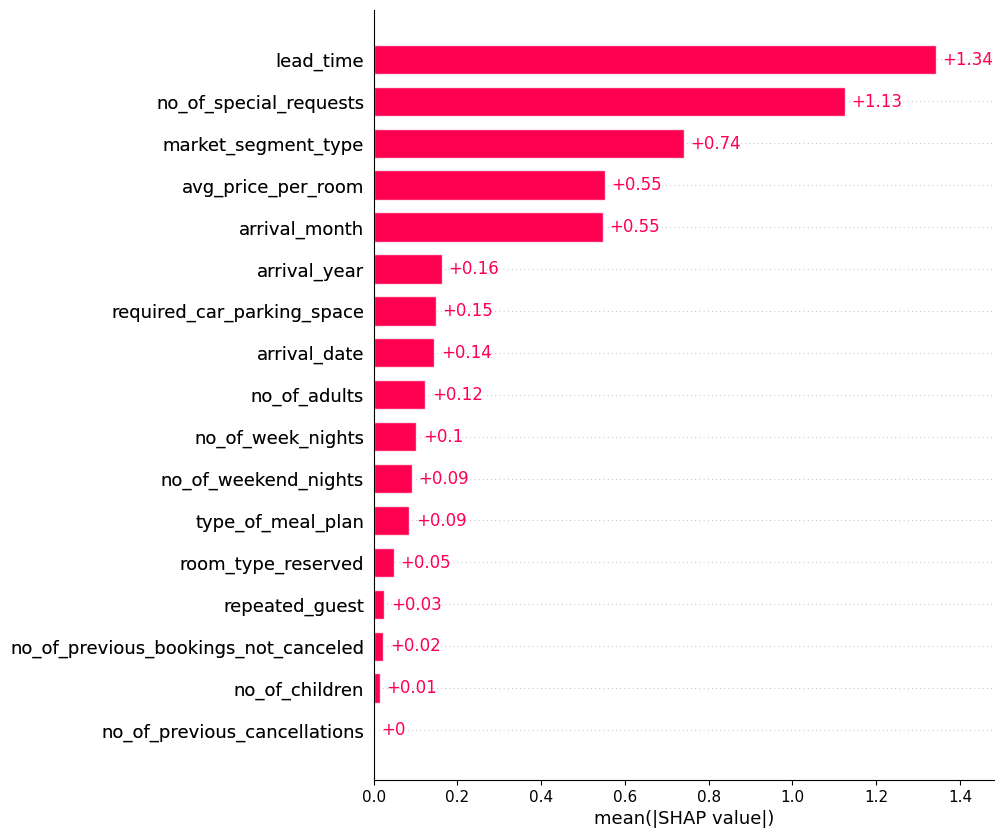

In [35]:
shap.plots.bar(hotels_shap_values, max_display=hotels_feat_count)

The Beeswarm plot reveals not only which features are important but also how they work.

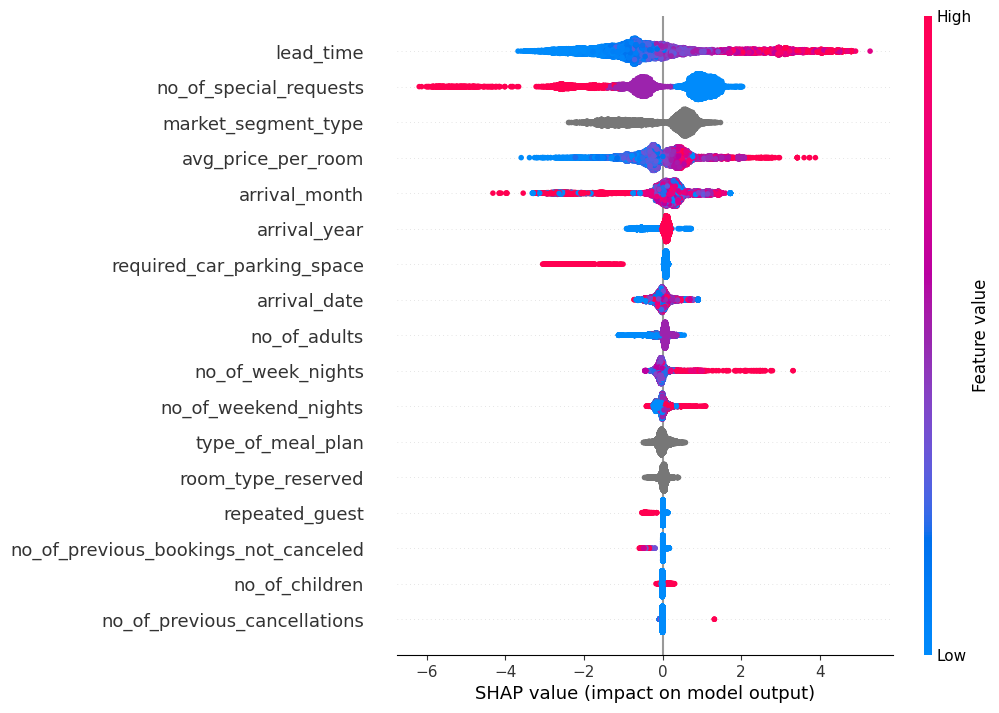

In [36]:
shap.plots.beeswarm(hotels_shap_values, max_display=X_hotels_val.shape[1])

In order to better understand the model's performance across different demographics, the dataset can be devided into logical business segments. For example, pick families with children and business travelers

In [50]:
X_hotels_group_family = X_hotels_val.query("no_of_adults > 1 and no_of_children >= 1 and avg_price_per_room < 90")

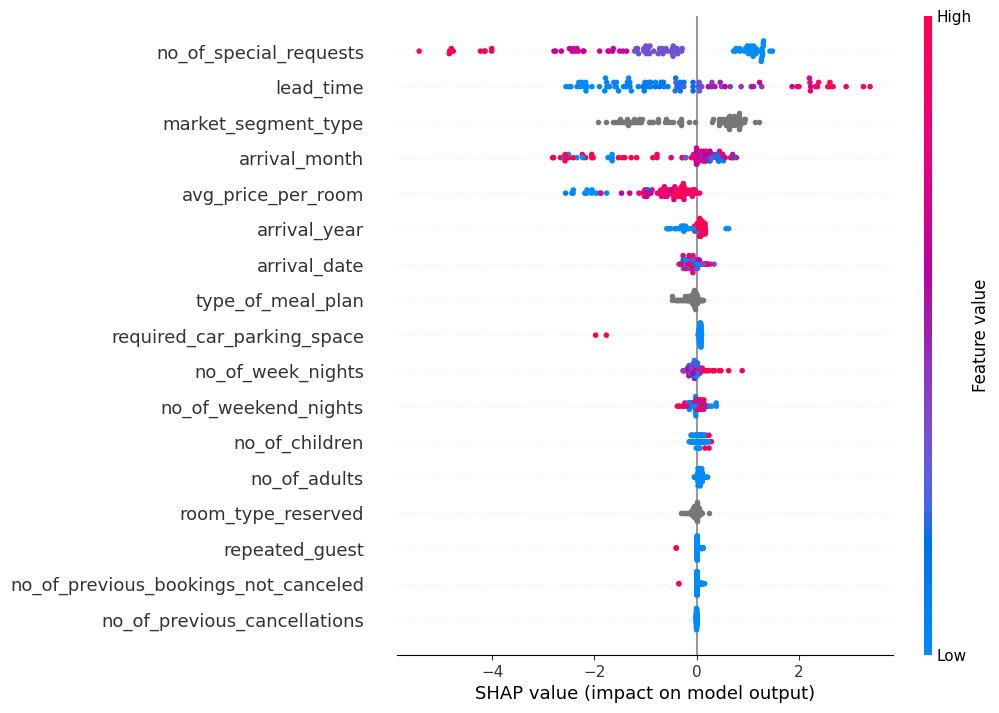

In [51]:
shap.plots.beeswarm(hotels_shap_values[[X_hotels_val.index.get_loc(idx) for idx in X_hotels_group_family.index]], max_display=hotels_feat_count)

There is a very clear split when it comes to high and low features values. For families, making special requests stands higher than lead time. The common trend of lead time is still applicable: families who book very far in advance are much more likely to cancel. Certain logic can be observed about arrival months: high values for arrival month (late-year/peak season) show negative SHAP values, meaning they decrease the likelihood of cancellation. That corresponds with the results of cancelation/non-cancelation per month countplot

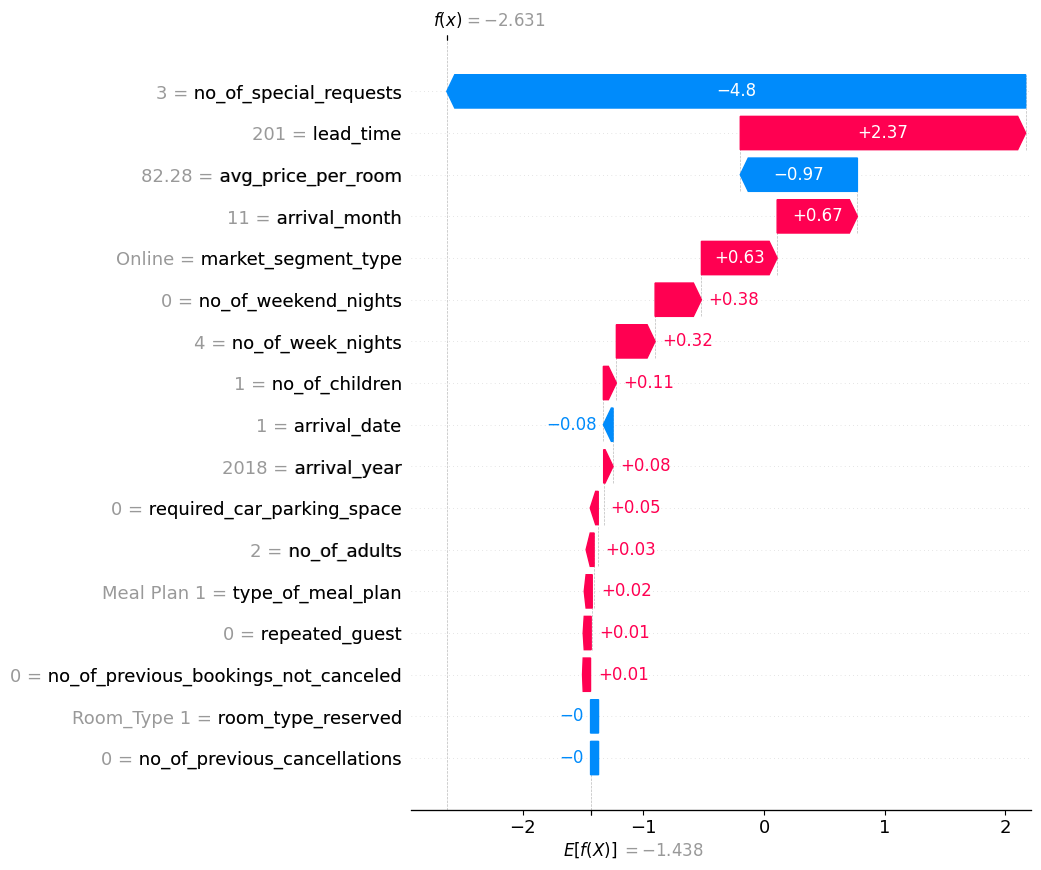

In [54]:
X_hotels_group_family_sample = X_hotels_group_family.sample(1, random_state=42)

shap.plots.waterfall(hotels_shap_values[X_hotels_group_family_sample.index[0]], max_display=hotels_feat_count)

Gets along the common trend of the whole group

In [56]:
X_hotels_group_business = X_hotels_val.query("market_segment_type == 'Corporate' and no_of_week_nights >= 1")

In [58]:
X_hotels_group_business

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
19,1,0,0,1,Meal Plan 1,1,Room_Type 1,8,2018,6,1,Corporate,1,0,6,98.0,1
111,1,0,0,1,Meal Plan 1,0,Room_Type 1,15,2018,2,19,Corporate,0,0,0,81.0,0
120,1,0,0,1,Meal Plan 1,0,Room_Type 1,0,2018,6,8,Corporate,1,0,2,92.5,0
153,1,0,0,1,Meal Plan 1,1,Room_Type 1,41,2018,12,20,Corporate,1,1,11,88.0,1
167,1,0,0,1,Meal Plan 1,0,Room_Type 1,99,2018,2,19,Corporate,0,0,0,81.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14384,1,0,0,1,Meal Plan 1,0,Room_Type 1,55,2018,7,7,Corporate,0,0,0,79.0,0
14465,1,0,0,1,Meal Plan 1,0,Room_Type 1,29,2018,2,23,Corporate,0,0,0,66.0,0
14497,2,0,1,1,Meal Plan 1,0,Room_Type 1,33,2018,1,25,Corporate,0,0,0,64.0,0
14503,1,0,0,3,Meal Plan 1,0,Room_Type 1,113,2018,5,31,Corporate,0,0,0,100.0,0


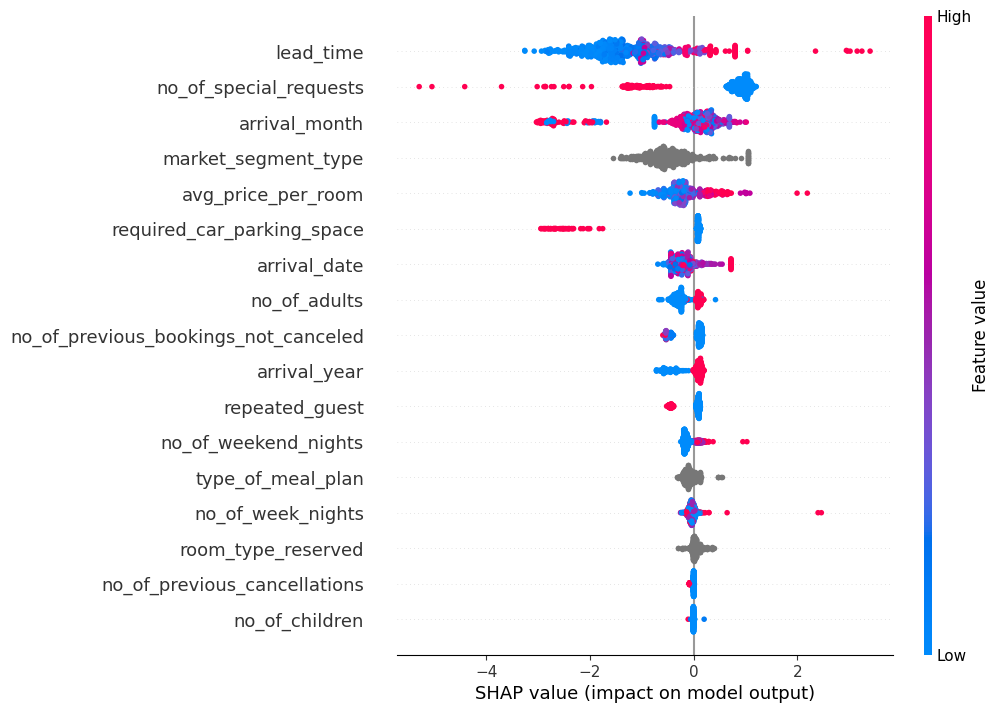

In [66]:
shap.plots.beeswarm(hotels_shap_values[[X_hotels_val.index.get_loc(idx) for idx in X_hotels_group_business.index]], max_display=hotels_feat_count)

The general trends of the whole dataset work here too. Lead time and number of special requests remain the top important features. One can also see that Features like required car parking space and being a repeated guest are strong negative predictors of cancellation, indicating high commitment

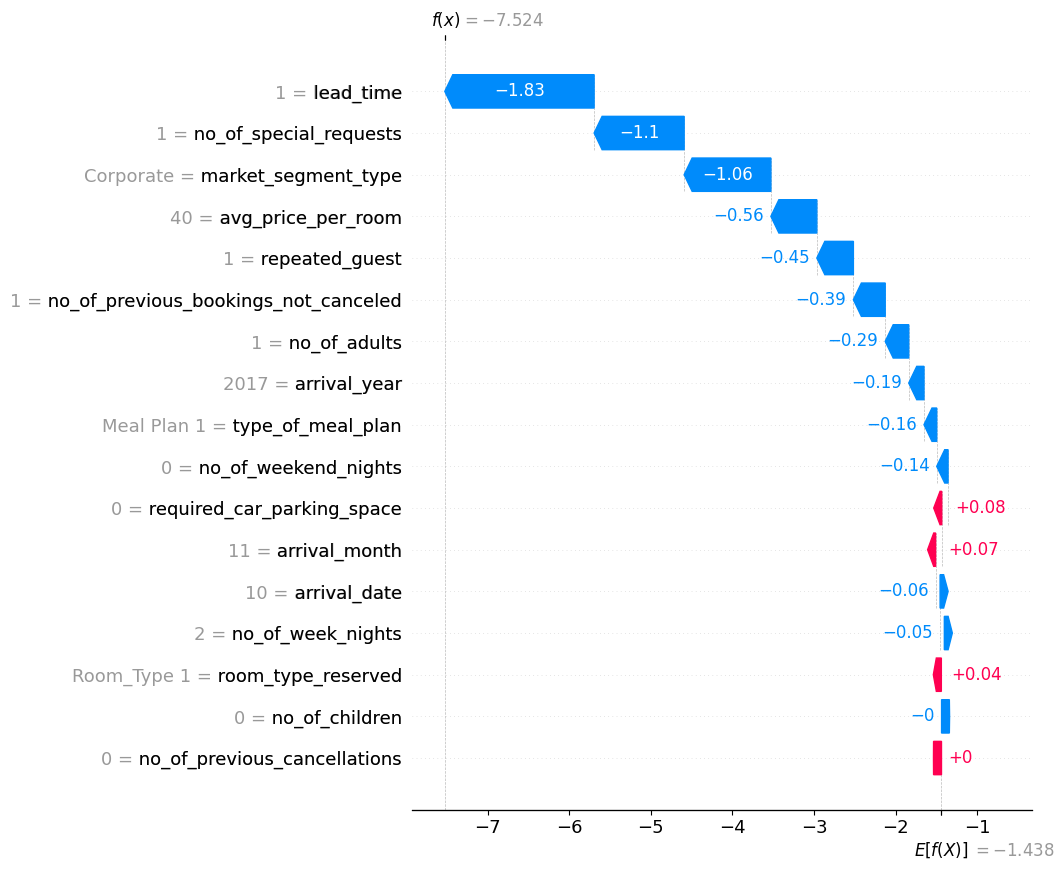

In [69]:
X_hotels_group_business_sample = X_hotels_group_business.sample(1, random_state=42)

shap.plots.waterfall(hotels_shap_values[X_hotels_group_business_sample.index[0]], max_display=hotels_feat_count)

Gets along the common trend of the whole group